# 01. A zero-inflated negative binomial GLM for disaster counts

The first model anyone would fit to this data. Each row is a country-year and a disaster class, the outcome is the count of events EM-DAT recorded, and the covariates are the ones the paper conditions on. The negative binomial handles the overdispersion, the zero inflation handles country-years with no record at all, the link is a log, and there is nothing latent.

The point is a baseline that runs clean, with posterior predictive checks that say where it fails, because that failure is what the next notebook has to fix.

Sections follow the workflow: the data, the model, what the priors imply, the fit, its diagnostics, what the posterior predicts, the posterior against the prior, and what was learned.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import preliz as pz
import pymc as pm
import xarray as xr

from arviz_plots import plot_energy
from checks import (
    count_summaries,
    observed_count_summaries,
    plot_country_counts,
    plot_coverage,
    plot_posterior_with_prior,
    plot_predictive_summaries,
    plot_rootograms,
    summarize,
)

from climate_risk.plotting import PALETTE, configure_plot_style
from climate_risk.replication_data import MODEL_FEATURES, create_replication_data
from climate_risk.sample import sample_or_load
from climate_risk.stats.scaling import standardize

configure_plot_style()

In [2]:
PROJECT_ROOT = next(p for p in Path.cwd().parents if (p / "pyproject.toml").exists())
CACHE_DIR = PROJECT_ROOT / "data"
FIT_DIR = Path("fits")

SEED = sum(map(ord, "climate_bayes"))

CLASSES = ["climate", "hydro"]
COUNTS = {"climate": "climatological_disasters", "hydro": "hydrological_disasters"}

# The paper's covariates, with population on a log scale. Standardized raw population puts China at
# eleven standard deviations, and a prior on a coefficient multiplying that has no scale to be set on.
FEATURES = [("ln_population" if name == "population" else name) for name in MODEL_FEATURES]

## The data

A country-year enters when it carries every covariate. EM-DAT reports a count as missing where it has no record of that class in that country-year, and those are filled with zero: the model is of what EM-DAT recorded, and an absent record is a recorded zero.

In [3]:
panel = (create_replication_data(CACHE_DIR)
         .to_pandas()
         .rename(columns={"ISO": "iso"})
         .assign(ln_population=lambda frame: np.log(frame["population"]))
         .dropna(subset=FEATURES)
         .reset_index(drop=True))

counts = panel[[COUNTS[name] for name in CLASSES]].fillna(0.0).astype(int)
counts.columns = CLASSES

_, scaled = standardize(panel, FEATURES)
SCALED_FEATURES = [f"{name}__standardized" for name in FEATURES]

print(f"{len(panel)} country-years, {panel['iso'].nunique()} countries, "
      f"{panel['date'].dt.year.min()} to {panel['date'].dt.year.max()}")
counts.describe().T

7710 country-years, 199 countries, 1981 to 2023


,count,mean,std,min,25%,50%,75%,max
climate,7710.00,0.21,0.58,0.00,0.00,0.00,0.00,10.00
hydro,7710.00,1.23,2.71,0.00,0.00,0.00,1.00,35.00


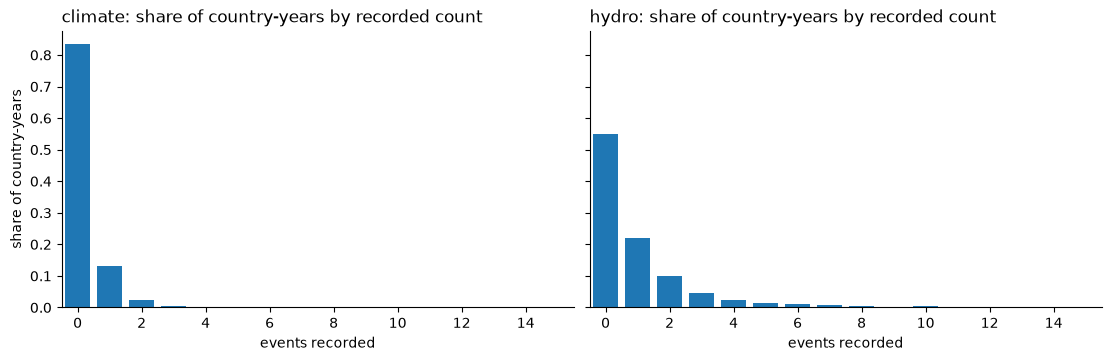

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)

for axis, name in zip(axes, CLASSES):
    observed = counts[name].value_counts(normalize=True).sort_index()
    axis.bar(observed.index, observed.to_numpy(), color=PALETTE["primary"], width=0.8)
    axis.set_title(f"{name}: share of country-years by recorded count", loc="left")
    axis.set_xlabel("events recorded")
    axis.set_xlim(-0.5, 15.5)

axes[0].set_ylabel("share of country-years")
plt.show()

## The model

Per class $c$ and country-year $i$,

$$
\begin{aligned}
y_{ic} &\sim \operatorname{ZeroInflatedNegativeBinomial}(\psi_c,\ \mu_{ic},\ \alpha_c) \\
\log \mu_{ic} &= a_c + x_i^\top \beta_c
\end{aligned}
$$

$\psi_c$ is the probability a country-year is in the counting regime at all, $\mu_{ic}$ the expected count when it is, and $\alpha_c$ the negative binomial's shape. The covariates are standardized, so $a_c$ is the log expected count at the average country-year and each $\beta$ is the change in log count per panel standard deviation.

The priors are weakly informative on the standardized scale. $a_c \sim \operatorname{Normal}(0, 1)$ puts the average country-year between a third of an event and three a year. $\beta_c \sim \operatorname{Normal}(0, 0.5)$ lets one standard deviation of a covariate move the count by up to a factor of $e$. $\alpha_c \sim \operatorname{Gamma}(2, 1)$ covers shapes from near-Poisson to very overdispersed, and $\psi_c \sim \operatorname{Beta}(2, 2)$ is flat-ish on the counting share.

In [5]:
coords = {
    "obs_idx": panel.index,
    "disaster": CLASSES,
    "feature": FEATURES,
}

with pm.Model(coords=coords) as zinb_model:
    X = pm.Data("X", scaled[SCALED_FEATURES].to_numpy(), dims=["obs_idx", "feature"])

    intercept = pm.Normal("intercept", 0, 1, dims=["disaster"])
    beta = pm.Normal("beta", 0, 0.5, dims=["feature", "disaster"])
    alpha = pm.Gamma("alpha", alpha=2, beta=1, dims=["disaster"])
    psi = pm.Beta("psi", 2, 2, dims=["disaster"])

    mu = pm.Deterministic("mu", pm.math.exp(intercept + X @ beta), dims=["obs_idx", "disaster"])

    pm.ZeroInflatedNegativeBinomial("y",
                                    psi=psi,
                                    mu=mu,
                                    alpha=alpha,
                                    observed=counts.to_numpy(),
                                    dims=["obs_idx", "disaster"])

zinb_model

## What the priors imply

Before the data, the model has a view on how many events a country-year records. Three summaries of it, against the same summaries of the data: the share of zeros, the mean count, and the largest count in the panel. A prior that cannot produce the observed values is too tight, and one that spends most of its mass on counts in the thousands is too loose.

Sampling: [alpha, beta, intercept, psi, y]


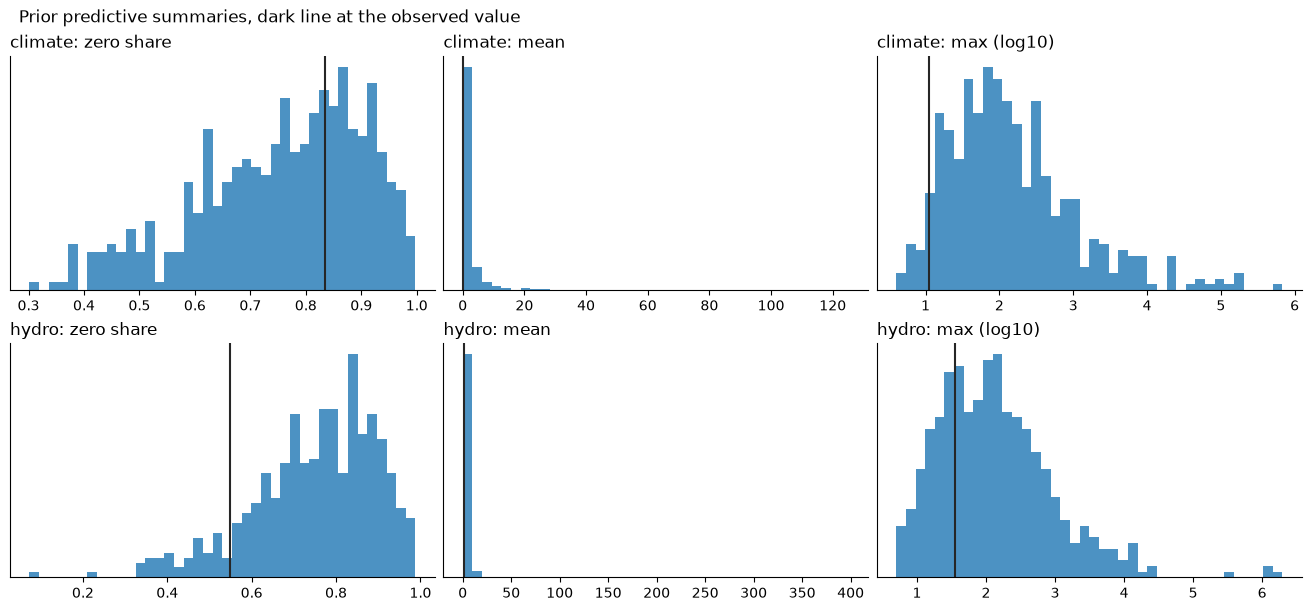

In [6]:
with zinb_model:
    prior_idata = pm.sample_prior_predictive(draws=500, random_seed=SEED)

observed_summaries = observed_count_summaries(counts)
plot_predictive_summaries(count_summaries(prior_idata.prior_predictive["y"]),
                          observed_summaries,
                          CLASSES,
                          "Prior predictive summaries, dark line at the observed value")

## The fit

The draws land in `fits/`, which is gitignored. `sample_or_load` reads the file back when it exists and does not check that the saved draws came from the data now in memory, so a fit outlives any change to the panel or the feature list. Pass `force_resample=True` after one.

In [7]:
sample_kwargs = dict(chains=8,
                     cores=8,
                     tune=500,
                     draws=250,
                     random_seed=SEED)

with zinb_model:
    idata = sample_or_load(fp=str(FIT_DIR / "zinb_glm.nc"), sample_kwargs=sample_kwargs)

PARAMETERS = ["intercept", "beta", "alpha", "psi"]
summarize(idata, PARAMETERS)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept[climate],-2.06,0.05,-2.14,-1.98,1003.82,1305.12,1.00,0.00,0.00
intercept[hydro],-0.53,0.02,-0.57,-0.50,1670.43,1482.42,1.01,0.00,0.00
"beta[ln_population_density, climate]",-0.22,0.03,-0.27,-0.17,3205.39,1195.73,1.01,0.00,0.00
"beta[ln_population_density, hydro]",0.02,0.02,-0.00,0.05,3073.23,1789.36,1.01,0.00,0.00
"beta[ln_gdp_pc, climate]",-0.60,0.24,-0.97,-0.22,341.45,483.23,1.04,0.01,0.01
"beta[ln_gdp_pc, hydro]",-0.04,0.15,-0.27,0.21,219.72,463.87,1.03,0.01,0.01
"beta[square_ln_gdp_pc, climate]",0.86,0.23,0.49,1.23,344.04,463.96,1.04,0.01,0.01
"beta[square_ln_gdp_pc, hydro]",0.07,0.15,-0.17,0.30,218.89,448.95,1.03,0.01,0.01
"beta[precip_deviation, climate]",-0.38,0.04,-0.44,-0.32,2858.37,1296.00,1.01,0.00,0.00
"beta[precip_deviation, hydro]",0.32,0.02,0.29,0.35,3036.91,1652.28,1.01,0.00,0.00


## Diagnostics

A GLM with eighteen parameters should mix without effort. Anything short of that is a sign the likelihood is flat somewhere.

0 divergences; worst r_hat 1.036; smallest bulk ESS 219 (beta[square_ln_gdp_pc, hydro])


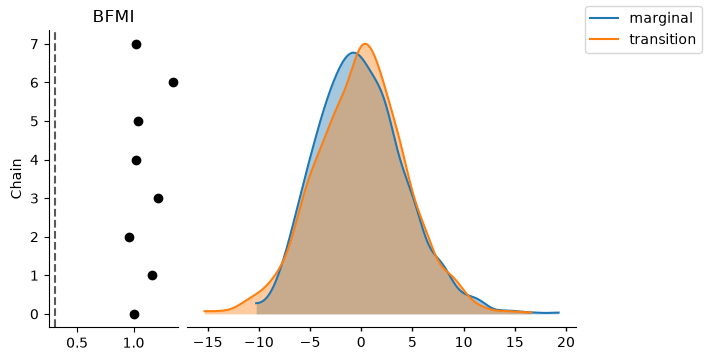

In [8]:
diagnostics = summarize(idata, PARAMETERS)[["ess_bulk", "ess_tail", "r_hat"]]
divergences = int(idata.sample_stats["diverging"].sum())

print(f"{divergences} divergences; worst r_hat {diagnostics['r_hat'].max():.3f}; "
      f"smallest bulk ESS {diagnostics['ess_bulk'].min():.0f} ({diagnostics['ess_bulk'].idxmin()})")
plot_energy(idata, backend="matplotlib", figure_kwargs={"figsize": (7, 3.5)})
plt.show()

## What the posterior predicts

Three checks, in order of how much they ask of the model. The first repeats the three summaries from the prior predictive with posterior draws. The second is the full count distribution. The third is the coverage of the predictive intervals at two levels, each country-year and each country's total over the panel.

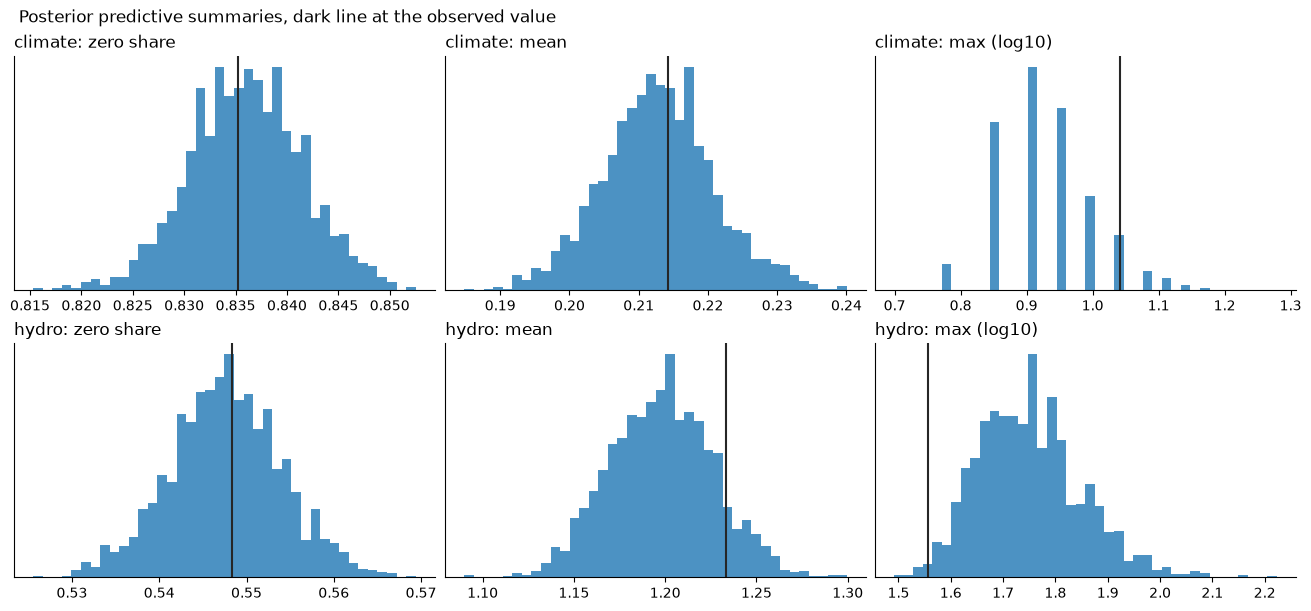

In [9]:
posterior_y = idata.posterior_predictive["y"]
plot_predictive_summaries(count_summaries(posterior_y),
                          observed_summaries,
                          CLASSES,
                          "Posterior predictive summaries, dark line at the observed value")

### The count distribution

A rootogram puts the predicted frequency of each count, with its interval, against the observed frequency as a point, on a square-root axis so that a frequency of 5 and a frequency of 5,000 are both legible. A point inside its interval is a count the model reproduces. A point above it is a count the data has more of than the model expects, below it fewer. The predictive tail runs far past the observed maximum, so the axis stops a little beyond it.

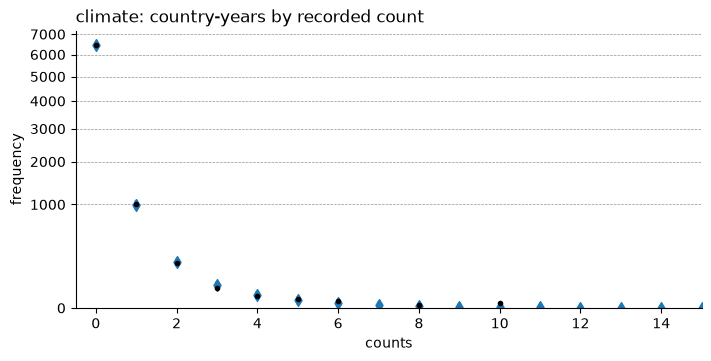

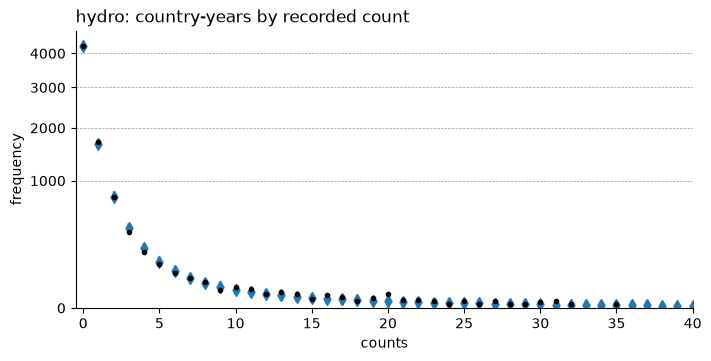

In [10]:
plot_rootograms(idata, counts, CLASSES)

### Interval coverage

For each observation, the posterior predictive gives a central interval at every width from 0% to 100%. A calibrated model's 50% intervals contain half the observations, its 90% intervals nine in ten, and so on. Each panel plots the actual coverage minus the nominal one across every width, so a calibrated model runs along the dashed zero line. A curve below the line means the intervals are too narrow: the model is more confident than it has a right to be. A curve above it means they are wider than the data need. The shaded band is the 99% range a calibrated model would produce with that many observations, computed from uniform draws. Counts are discrete, so the probability integral transform behind the curve is randomized within the atom at each observed value.

The top row is one observation per country-year, which is the level the model was fit at. The bottom row is one observation per country, its total over the panel. The GLM has no country term, so it treats a country's 43 rows as exchangeable with everyone else's, and the totals are where that assumption gets tested.

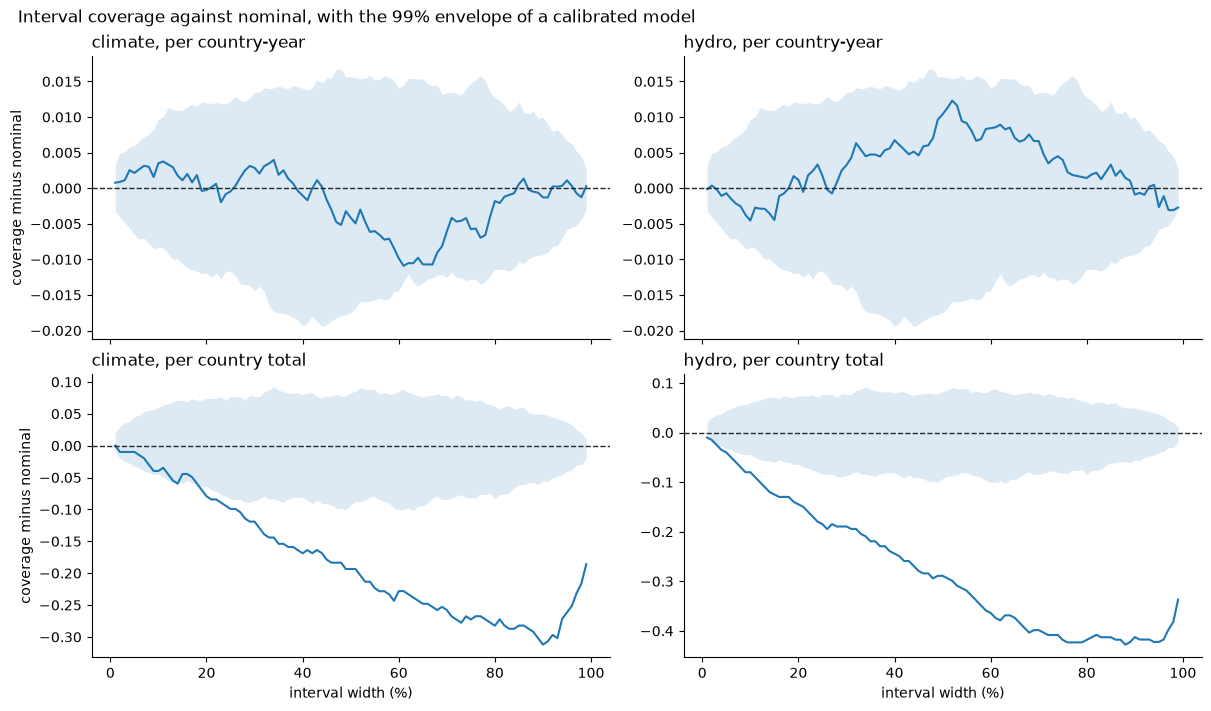

In [11]:
plot_coverage(idata, panel["iso"].to_numpy(), CLASSES)

## The posterior against the prior

Each panel is the posterior of one parameter in blue over its prior in orange. A posterior sitting on its prior is a parameter the data said nothing about. One in the prior's tail is a parameter the data argued with, and the prior may be too tight.

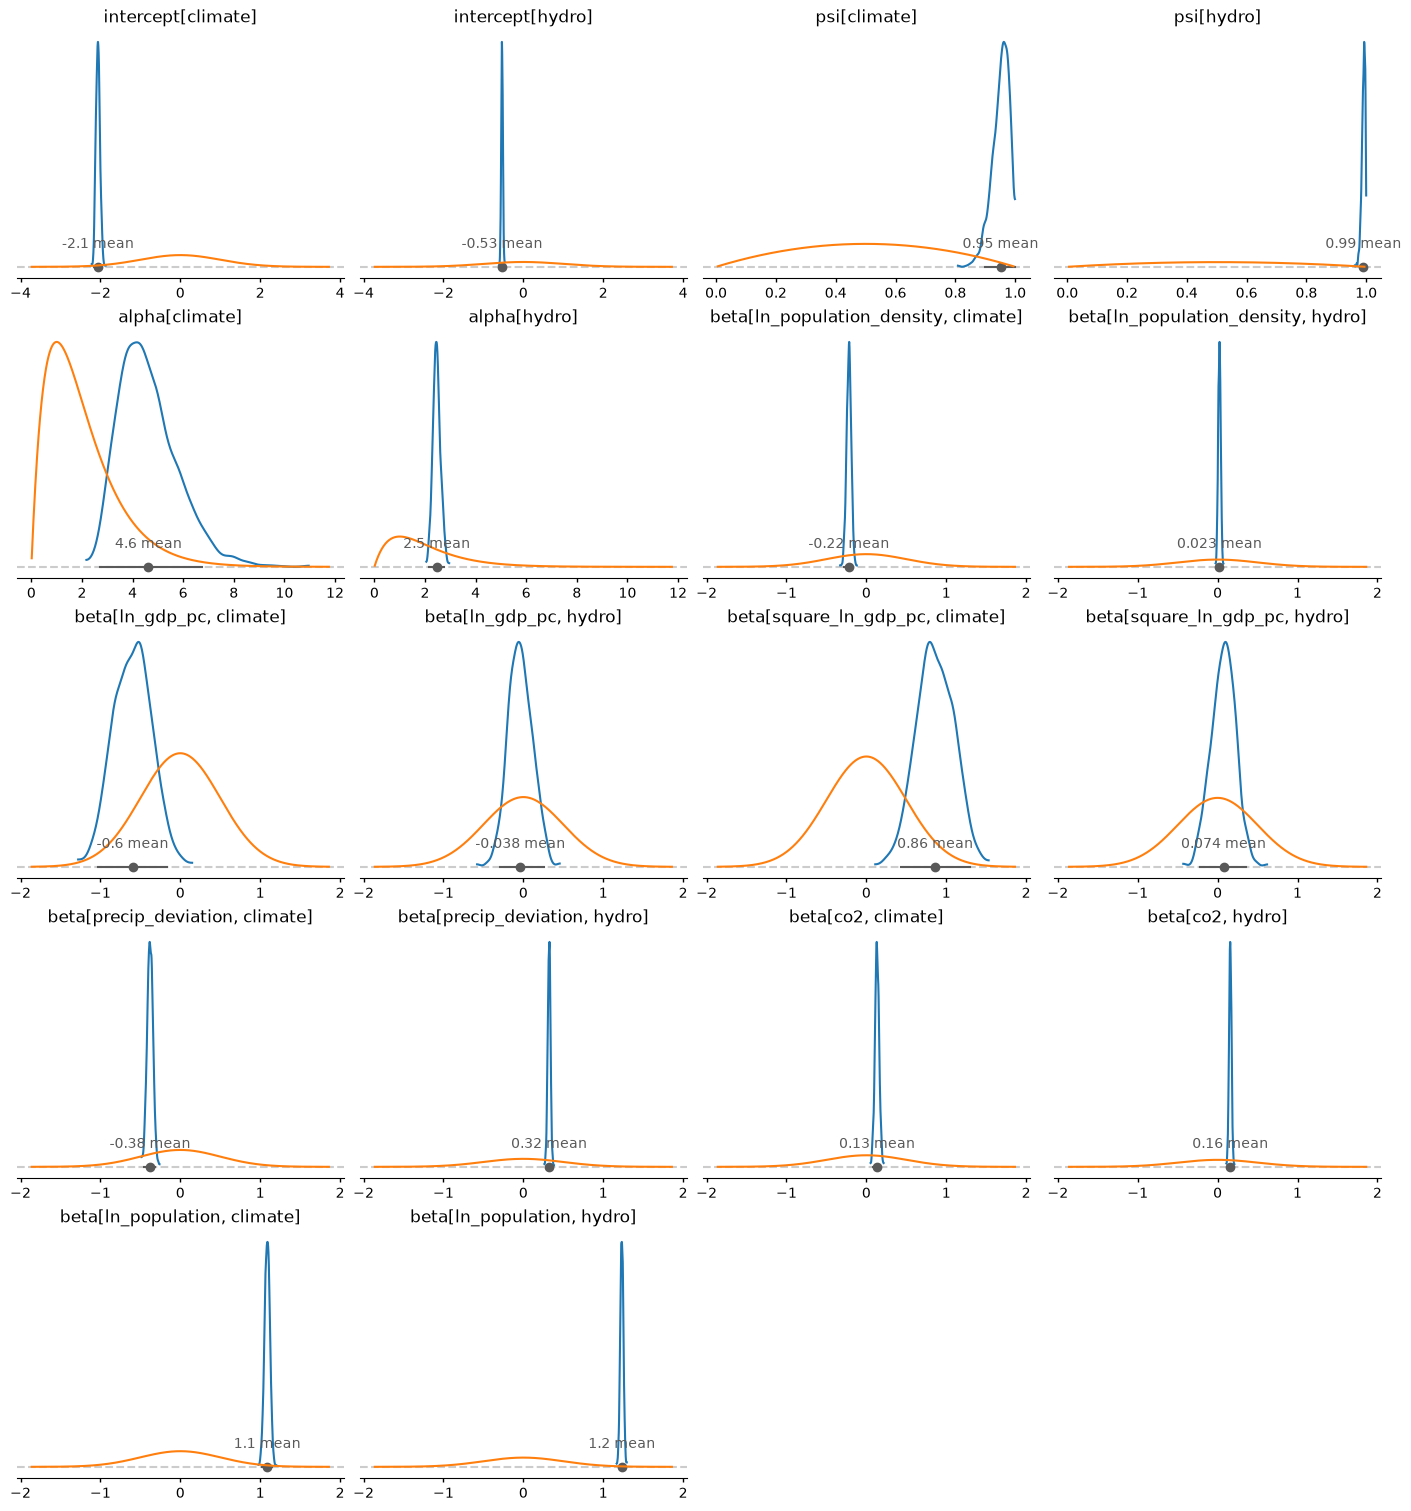

In [12]:
posterior = idata.posterior
of_interest = xr.Dataset({
    **{f"intercept[{name}]": posterior["intercept"].sel(disaster=name, drop=True) for name in CLASSES},
    **{f"psi[{name}]": posterior["psi"].sel(disaster=name, drop=True) for name in CLASSES},
    **{f"alpha[{name}]": posterior["alpha"].sel(disaster=name, drop=True) for name in CLASSES},
    **{f"beta[{feature}, {name}]": posterior["beta"].sel(feature=feature, disaster=name, drop=True)
       for feature in FEATURES for name in CLASSES},
})

priors = {
    **{f"intercept[{name}]": pz.Normal(0, 1) for name in CLASSES},
    **{f"psi[{name}]": pz.Beta(2, 2) for name in CLASSES},
    **{f"alpha[{name}]": pz.Gamma(alpha=2, beta=1) for name in CLASSES},
    **{f"beta[{feature}, {name}]": pz.Normal(0, 0.5) for feature in FEATURES for name in CLASSES},
}

fig = plot_posterior_with_prior(of_interest, priors)
plt.show()

## A few countries over time

The checks above are aggregate. This is what the model says about single countries, year by year: the observed count as points, the posterior predictive mean as a line, and central intervals from 5% to 95% stacked as graded shading, so the darker the band the more of the predictive mass it holds. Laos is the country the work is for, China is the country with the most events, and Bangladesh is a mid-sized country with a heavy hydrometeorological record.

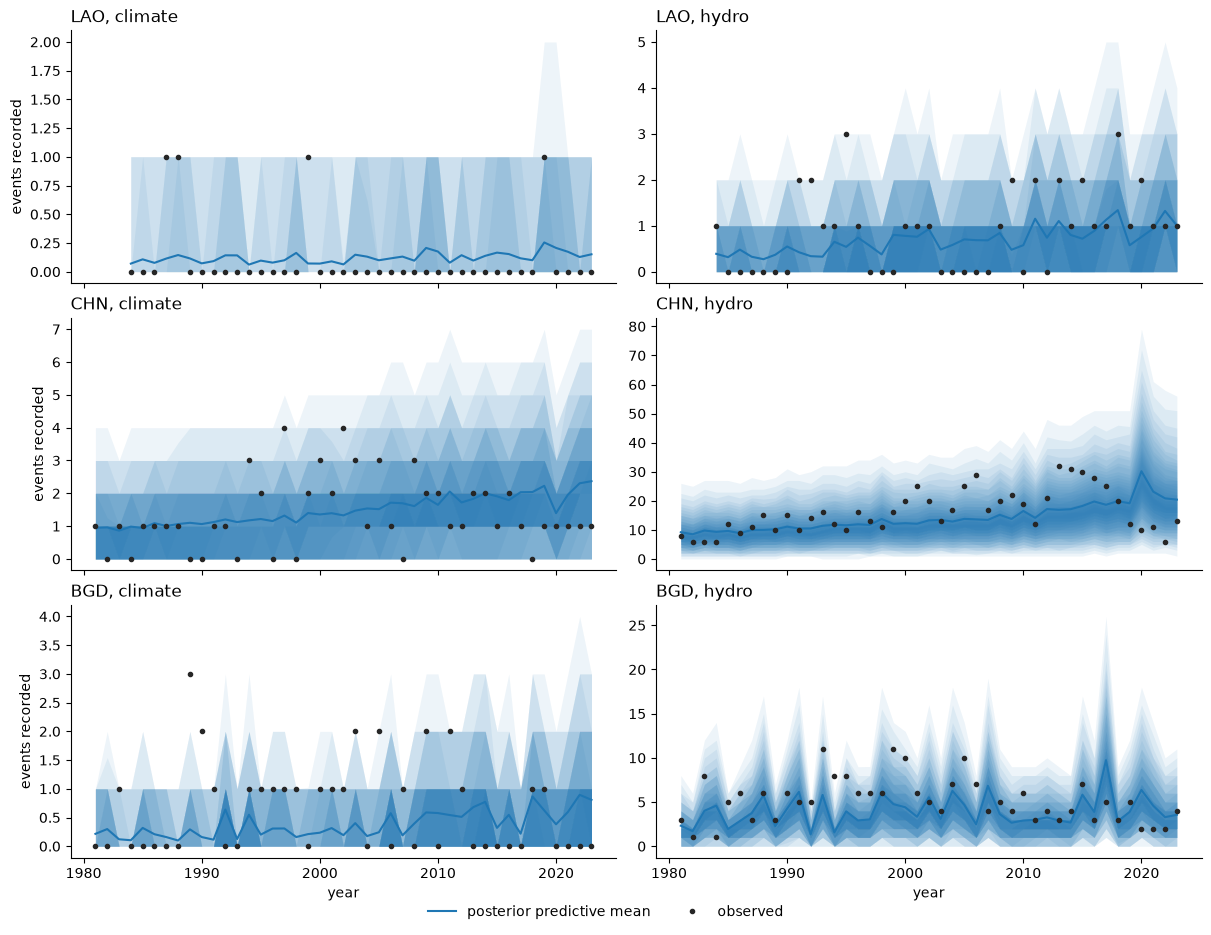

In [13]:
plot_country_counts(posterior_y, panel, counts, ["LAO", "CHN", "BGD"], CLASSES)

## What was learned

*The fit is clean.* No divergences, every r_hat at or below 1.04, and the only slow pair is `ln_gdp_pc` with its square, which is collinear by construction.

*The zero inflation is not needed.* $\psi$ is 0.95 for climatological and 0.99 for hydrometeorological events, so the negative binomial's own zeros account for almost every country-year with no record. The next model can be a plain negative binomial without losing anything the checks can see.

*Population carries the count.* One panel standard deviation of log population multiplies the expected count by $e^{1.1}$ for climatological and $e^{1.2}$ for hydrometeorological events, and it is the one coefficient whose posterior sits in the tail of its `Normal(0, 0.5)` prior. Precipitation deviation goes the right way for both classes: wetter years bring more floods and storms, drier years more droughts and fires. CO2 is positive for both, at 0.13 and 0.16 per standard deviation. On a covariate with no within-country variation that is a year effect, and it reads as one.

*The row-level checks pass and the country-level one fails.* The rootograms and the per-country-year coverage are inside the band at every interval width. The country totals are not. The 90% interval contains about 60% of countries' climatological totals and 47% of their hydrometeorological ones, and the coverage curve falls further the wider the interval gets. The country plots show the same thing one country at a time. China's hydrometeorological record runs above the predictive mean for the whole of the 2010s and Laos's runs below it for the 1980s, and nothing in the model can hold a residual that persists for a decade. The covariates do not carry what makes one country's record differ from another's, and the negative binomial's dispersion, fitted to the pooled rows, cannot absorb it.

*Next.* A hierarchical country intercept on the same negative binomial. It is the smallest change that addresses the check that failed, and it raises the question of what a country effect absorbs from the covariates.